# MVRV Strategy vs Uniform DCA - 2018-2023

In [1]:
import sys
import json
import polars as pl
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import date
import stacksats
from matplotlib import pyplot as plt


_root = Path.cwd()
while not (_root / "src").exists():
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from src import config as src_config, data_utils, plots, strategy_utils

TRAIN_PATH = src_config.TRAIN_PATH
PROCESSED_PATH = src_config.DATA_DIR / "processed"
STACKSATS_DATA_PATH = src_config.STACKSATS_DATA_PATH
RAW_PATH = src_config.RAW_PATH

data_utils.check_stacksats_data(STACKSATS_DATA_PATH, RAW_PATH)

True

In [2]:
from stacksats import StrategyRunner, ExportConfig, UniformStrategy, MVRVStrategy

# Load data
btc_df = pl.read_parquet(STACKSATS_DATA_PATH)
btc_df = btc_df.with_columns(pl.col('date').cast(pl.Datetime))

btc_filtered = (
    btc_df
    .filter(
        (pl.col("date") >= pl.datetime(2018, 1, 1)) &
        (pl.col("date") <= pl.datetime(2023, 12, 31)) &
        pl.col("price_usd").is_not_null()
    )
    .sort("date")
)

runner = StrategyRunner()
print(f"Loaded {btc_filtered.height} rows from 2018-01-01 to 2023-12-31")



Loaded 2191 rows from 2018-01-01 to 2023-12-31


## 1: MVRV Strategy - Default Min Weight (1e-5)
Year-by-year backtest of `MVRVStrategy` vs uniform DCA using the default minimum daily weight floor of `1e-5`.

In [3]:
cycle_results = {}

# Only iterate cycles that overlap with btc_filtered (2018-2023)
relevant_cycles = [c for c in plots.calendar_cycles if c["end"] >= "2018-01-01"]

for cycle in relevant_cycles:
    result = strategy_utils.process_cycle_year_by_year(
        cycle=cycle,
        btc_data=btc_filtered,
        runner=runner,
        dynamic_strategy=MVRVStrategy(),
        total_budget_usd=1000.0,
        top_buy_quantile=0.90
    )

    cycle_results[cycle["label"]] = result

cols = plots.StrategyColumns(
    weight="dynamic_weight",
    spd="sats_per_dollar_dynamic",
    sats_accum="sats_accum_dynamic",
)

# Combine all 4 cycles into one DataFrame
combined_plot_df = pd.concat(
    [r["plot_df"] for r in cycle_results.values()]
).sort_values("date").reset_index(drop=True)

# per year plots
year_plots = plots.plot_strategy_by_year(combined_plot_df, cols, "MVRV (min=1e-5)")
plt.show()


Processing Cycle 3: 2018-2021
shape: (1, 3)
┌─────────────────────┬─────────────────────┬──────┐
│ min_date            ┆ max_date            ┆ rows │
│ ---                 ┆ ---                 ┆ ---  │
│ datetime[μs]        ┆ datetime[μs]        ┆ u32  │
╞═════════════════════╪═════════════════════╪══════╡
│ 2018-01-01 00:00:00 ┆ 2021-12-31 00:00:00 ┆ 1461 │
└─────────────────────┴─────────────────────┴──────┘
2018: exported 365 rows
2018: exported 365 rows
2019: exported 365 rows
2019: exported 365 rows
2020: exported 365 rows
2020: exported 365 rows
2021: exported 365 rows
2021: exported 365 rows

Processing Cycle 4: 2022-2023
shape: (1, 3)
┌─────────────────────┬─────────────────────┬──────┐
│ min_date            ┆ max_date            ┆ rows │
│ ---                 ┆ ---                 ┆ ---  │
│ datetime[μs]        ┆ datetime[μs]        ┆ u32  │
╞═════════════════════╪═════════════════════╪══════╡
│ 2022-01-01 00:00:00 ┆ 2023-12-31 00:00:00 ┆ 730  │
└─────────────────────┴──────

## 2: MVRV Strategy - Custom Min Weight (0.00112)
Re-runs the same analysis with a higher minimum daily weight floor (`0.00112`). This prevents end-of-year budget dump by ensuring a larger baseline spend each day. 

In [4]:
# 1. First, import the underlying modules that hold the hardcoded constants
import stacksats.framework_contract
import stacksats.runner.validation
import stacksats.strategy_types._legacy
import stacksats.model_development.public

# 2. Dynamically overwrite the minimum daily weight to 0.0 in memory
new_min_buy = 0.00112
stacksats.framework_contract.MIN_DAILY_WEIGHT = new_min_buy
stacksats.runner.validation.MIN_DAILY_WEIGHT = new_min_buy
stacksats.strategy_types._legacy.MIN_DAILY_WEIGHT = new_min_buy
stacksats.model_development.public.MIN_DAILY_WEIGHT = new_min_buy
stacksats.model_development.public.MIN_W = new_min_buy



In [5]:
cycle_results = {}

for cycle in relevant_cycles:
    result = strategy_utils.process_cycle_year_by_year(
        cycle=cycle,
        btc_data=btc_filtered,
        runner=runner,
        dynamic_strategy=MVRVStrategy(),
        total_budget_usd=1000.0,
        top_buy_quantile=0.90
    )

    cycle_results[cycle["label"]] = result

# Combine all 4 cycles into one DataFrame
combined_plot_df = pd.concat(
    [r["plot_df"] for r in cycle_results.values()]
).sort_values("date").reset_index(drop=True)

# per year plots
year_plots = plots.plot_strategy_by_year(combined_plot_df, cols, f"MVRV (min={new_min_buy})")
plt.show()


Processing Cycle 3: 2018-2021
shape: (1, 3)
┌─────────────────────┬─────────────────────┬──────┐
│ min_date            ┆ max_date            ┆ rows │
│ ---                 ┆ ---                 ┆ ---  │
│ datetime[μs]        ┆ datetime[μs]        ┆ u32  │
╞═════════════════════╪═════════════════════╪══════╡
│ 2018-01-01 00:00:00 ┆ 2021-12-31 00:00:00 ┆ 1461 │
└─────────────────────┴─────────────────────┴──────┘
2018: exported 365 rows
2018: exported 365 rows
2019: exported 365 rows
2019: exported 365 rows
2020: exported 365 rows
2020: exported 365 rows
2021: exported 365 rows
2021: exported 365 rows

Processing Cycle 4: 2022-2023
shape: (1, 3)
┌─────────────────────┬─────────────────────┬──────┐
│ min_date            ┆ max_date            ┆ rows │
│ ---                 ┆ ---                 ┆ ---  │
│ datetime[μs]        ┆ datetime[μs]        ┆ u32  │
╞═════════════════════╪═════════════════════╪══════╡
│ 2022-01-01 00:00:00 ┆ 2023-12-31 00:00:00 ┆ 730  │
└─────────────────────┴──────

In [6]:
# reset min weight
_DEFAULT_MIN_WEIGHT = 1e-5

stacksats.framework_contract.MIN_DAILY_WEIGHT      = _DEFAULT_MIN_WEIGHT
stacksats.runner.validation.MIN_DAILY_WEIGHT       = _DEFAULT_MIN_WEIGHT
stacksats.strategy_types._legacy.MIN_DAILY_WEIGHT  = _DEFAULT_MIN_WEIGHT
stacksats.model_development.public.MIN_DAILY_WEIGHT = _DEFAULT_MIN_WEIGHT
stacksats.model_development.public.MIN_W            = _DEFAULT_MIN_WEIGHT

print(f"MIN_DAILY_WEIGHT reset to {_DEFAULT_MIN_WEIGHT}")

MIN_DAILY_WEIGHT reset to 1e-05


## 3 (Exploratory): Min-Buy Sensitivity Analysis

Tests total sats accumulated across a range of minimum daily weight thresholds (`1e-5` to `0.002`). Shows the trade-off between concentrated buying and preventing large end-of-year budget dumps.

> **Note**: depends on `btc_df` and `runner` from the Data Loading cell above.

Running threshold sensitivity test...
Testing threshold: 0.00001...
Testing threshold: 0.00023...
Testing threshold: 0.00045...
Testing threshold: 0.00067...
Testing threshold: 0.00089...
Testing threshold: 0.00112...
Testing threshold: 0.00134...
Testing threshold: 0.00156...
Testing threshold: 0.00178...
Testing threshold: 0.00200...
MIN_DAILY_WEIGHT reset to 1e-05


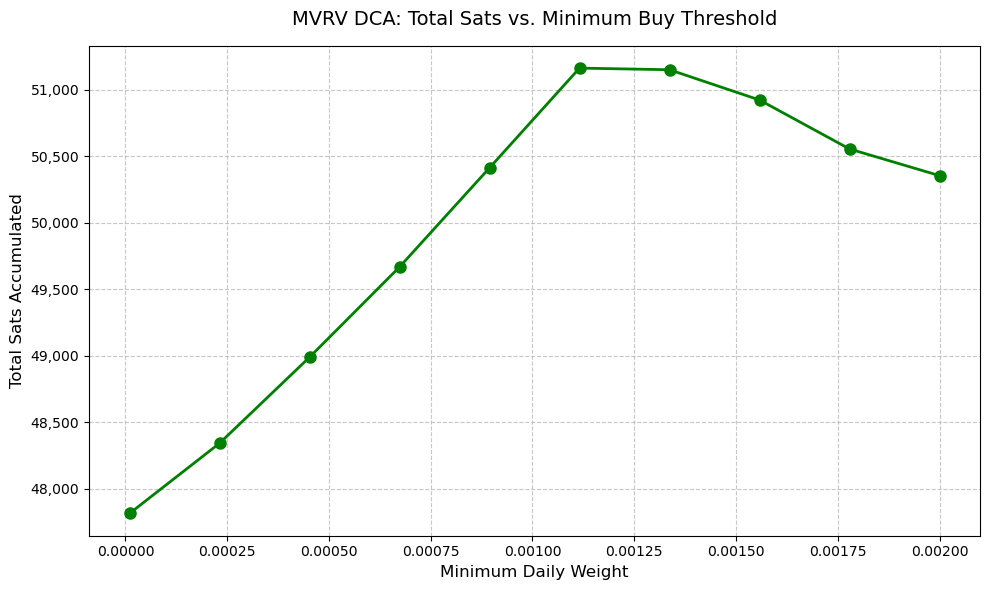

  min_weight=0.00001  →  47,815 sats
  min_weight=0.00023  →  48,342 sats
  min_weight=0.00045  →  48,989 sats
  min_weight=0.00067  →  49,668 sats
  min_weight=0.00089  →  50,414 sats
  min_weight=0.00112  →  51,164 sats
  min_weight=0.00134  →  51,152 sats
  min_weight=0.00156  →  50,924 sats
  min_weight=0.00178  →  50,556 sats
  min_weight=0.00200  →  50,355 sats


In [7]:
# Define test thresholds from 0.00001 to 0.001
test_thresholds = np.linspace(0.00001, 0.002, num=10)
sats_results = []

print("Running threshold sensitivity test...")

for min_val in test_thresholds:
    print(f"Testing threshold: {min_val:.5f}...")
    
    # 1. Apply the monkey patch for this specific loop
    stacksats.framework_contract.MIN_DAILY_WEIGHT = min_val
    stacksats.runner.validation.MIN_DAILY_WEIGHT = min_val
    stacksats.strategy_types._legacy.MIN_DAILY_WEIGHT = min_val
    stacksats.model_development.public.MIN_DAILY_WEIGHT = min_val
    stacksats.model_development.public.MIN_W = min_val
    
    all_dynamic = []
    
    # 2. Run the strategy for all years
    for year in range(2018, 2024):
        config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
        dyn = runner.export(MVRVStrategy(), config, btc_df=btc_df).to_dataframe()
        
        # Flatten Leap Years
        dyn_flat = dyn.group_by('date').agg([
            pl.col('weight').mean().alias('dynamic_weight'),
            pl.col('price_usd').first()
        ])
        all_dynamic.append(dyn_flat)
        
    # 3. Calculate total sats for this specific threshold
    dynamic_weights = pl.concat(all_dynamic)
    dynamic_weights = dynamic_weights.with_columns(
        ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated')
    )
    
    total_sats = dynamic_weights['sats_accumulated'].sum()
    sats_results.append(total_sats)

# Reset to default after loop
stacksats.framework_contract.MIN_DAILY_WEIGHT      = _DEFAULT_MIN_WEIGHT
stacksats.runner.validation.MIN_DAILY_WEIGHT       = _DEFAULT_MIN_WEIGHT
stacksats.strategy_types._legacy.MIN_DAILY_WEIGHT  = _DEFAULT_MIN_WEIGHT
stacksats.model_development.public.MIN_DAILY_WEIGHT = _DEFAULT_MIN_WEIGHT
stacksats.model_development.public.MIN_W            = _DEFAULT_MIN_WEIGHT
print(f"MIN_DAILY_WEIGHT reset to {_DEFAULT_MIN_WEIGHT}")

plt.figure(figsize=(10, 6))
plt.plot(test_thresholds, sats_results, marker="o", color="green", linewidth=2, markersize=8)
plt.title("MVRV DCA: Total Sats vs. Minimum Buy Threshold", fontsize=14, pad=15)
plt.xlabel("Minimum Daily Weight", fontsize=12)
plt.ylabel("Total Sats Accumulated", fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter("{x:,.0f}"))
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

for threshold, sats in zip(test_thresholds, sats_results):
    print(f"  min_weight={threshold:.5f}  →  {sats:,.0f} sats")


## 4 (Exploratory): BacktestConfig Score Comparison

Uses the stacksats `BacktestConfig` runner to score strategies over the full 2018–2023 range using hundreds of overlapping 365-day windows.
Compares: Uniform DCA baseline, MVRV default (1e-5), MVRV custom (0.00112).

> **Note**: depends on `btc_df` and `runner` from the Data Loading cell above.

In [8]:
from stacksats import StrategyRunner, BacktestConfig, UniformStrategy, MVRVStrategy

# Setup Backtest Config (We just give it the full 6-year range!)
# It will internally generate hundreds of overlapping 365-day backtests and grade them.
backtest_cfg = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

# ==========================================
# TEST 1: Baseline Uniform DCA
# ==========================================
print("Running Baseline DCA...")
base_result = runner.backtest(UniformStrategy(), backtest_cfg, btc_df=btc_df)
print(f"-> Baseline Score: {base_result.score:.2f}")
print("-" * 40)

# ==========================================
# TEST 2: Default MVRV (Min Weight = 1e-5)
# ==========================================
# Ensure it is at default
stacksats.framework_contract.MIN_DAILY_WEIGHT = _DEFAULT_MIN_WEIGHT
stacksats.runner.validation.MIN_DAILY_WEIGHT = _DEFAULT_MIN_WEIGHT
stacksats.strategy_types._legacy.MIN_DAILY_WEIGHT  = _DEFAULT_MIN_WEIGHT
stacksats.model_development.public.MIN_DAILY_WEIGHT = _DEFAULT_MIN_WEIGHT
stacksats.model_development.public.MIN_W            = _DEFAULT_MIN_WEIGHT

print("Running Default MVRV (1e-5 floor)...")
mvrv_default_result = runner.backtest(MVRVStrategy(), backtest_cfg, btc_df=btc_df)
print(f"-> Default MVRV Score: {mvrv_default_result.score:.2f}")
print(f"-> Default MVRV Win Rate: {mvrv_default_result.win_rate:.1f}%")
print("-" * 40)

# ==========================================
# TEST 3: Custom MVRV (Min Weight = 0.00112)
# ==========================================
# Apply your custom monkey patch
custom_min = 0.00112
stacksats.framework_contract.MIN_DAILY_WEIGHT = custom_min
stacksats.runner.validation.MIN_DAILY_WEIGHT = custom_min
stacksats.strategy_types._legacy.MIN_DAILY_WEIGHT = custom_min
stacksats.model_development.public.MIN_DAILY_WEIGHT = custom_min
stacksats.model_development.public.MIN_W = custom_min

print(f"Running Custom MVRV ({custom_min} floor)...")
mvrv_custom_result = runner.backtest(MVRVStrategy(), backtest_cfg, btc_df=btc_df)
print(f"-> Custom MVRV Score: {mvrv_custom_result.score:.2f}")
print(f"-> Custom MVRV Win Rate: {mvrv_custom_result.win_rate:.1f}%")
print("-" * 40)

# (Reset to default just to be safe)
stacksats.framework_contract.MIN_DAILY_WEIGHT = _DEFAULT_MIN_WEIGHT
stacksats.runner.validation.MIN_DAILY_WEIGHT = _DEFAULT_MIN_WEIGHT
stacksats.strategy_types._legacy.MIN_DAILY_WEIGHT  = _DEFAULT_MIN_WEIGHT
stacksats.model_development.public.MIN_DAILY_WEIGHT = _DEFAULT_MIN_WEIGHT
stacksats.model_development.public.MIN_W            = _DEFAULT_MIN_WEIGHT
print(f"MIN_DAILY_WEIGHT reset to {_DEFAULT_MIN_WEIGHT}")


Running Baseline DCA...
-> Baseline Score: 18.65
----------------------------------------
Running Default MVRV (1e-5 floor)...
-> Default MVRV Score: 23.51
-> Default MVRV Win Rate: 41.8%
----------------------------------------
Running Custom MVRV (0.00112 floor)...
-> Custom MVRV Score: 28.66
-> Custom MVRV Win Rate: 39.4%
----------------------------------------
MIN_DAILY_WEIGHT reset to 1e-05


-> tehcnically -> work well and prevent situation where like mass buy at the end of the year -> but overall not ass good as the other